# Centrifuge vibration workflow

A compact workflow for 40 labeled runs. The 20 balanced/good waveforms are from the supplied stable 700 rpm and 1400 rpm recordings; the 20 imbalanced waveforms are from the supplied unstable 700 rpm and 1400 rpm recordings. Segments used for training follow `data/run_metadata.csv`.

The notebook concatenates sample data, calculates per-run standard deviation and NumPy FFT peaks, plots the vibration summaries, then compares three Sequential CNNs. Model selection uses validation loss; the held-out test set is used only for the selected model.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT / "hackathon"
DATA_DIR = ROOT / "data"
AXES = ["X", "Y", "Z"]
COLORS = {"X": "#e53935", "Y": "#43a047", "Z": "#1e88e5"}
metadata = pd.read_csv(DATA_DIR / "run_metadata.csv")

## Load, concatenate, and engineer run features

The CNN receives the stored X/Y/Z waveforms directly. The combined sample table also retains time step, temperature, density, labels, tube positions, and volumes. Temperature and density remain blank until measured.

In [18]:
files = sorted(DATA_DIR.glob("*rpm_*_run*.csv"))
assert len(files) == len(metadata) == 40
meta = metadata.set_index("file")
run_arrays, sample_frames, feature_rows = [], [], []

for path in files:
    raw = pd.read_csv(path)
    info = meta.loc[path.name]
    t = raw["Timestamp"].to_numpy(float)
    dt = float(np.median(np.diff(t)))
    xyz = raw[AXES].to_numpy(np.float32)
    assert xyz.shape == (120, 3), f"Unexpected shape in {path.name}: {xyz.shape}"
    run_id = info["run_id"]
    label = int(info["label_imbalanced"])
    run_arrays.append((run_id, xyz, label))
    sample_frames.append(pd.DataFrame({
        "run_id": run_id, "file": path.name, "Timestamp": t,
        "time_from_start_s": t - t[0], "time_step_s": dt,
        "X": xyz[:, 0], "Y": xyz[:, 1], "Z": xyz[:, 2],
        "rpm": int(info["rpm"]), "condition": path.stem.split("rpm_", 1)[1].rsplit("_run", 1)[0],
        "label_imbalanced": label, "sample_temperature_C": info["sample_temperature_C"],
        "liquid_density_g_per_mL": info["liquid_density_g_per_mL"],
        "rotor_positions_clockwise": info["rotor_positions_clockwise"],
        "position_volume_map": info["position_volume_map"],
    }))
    row = {"run_id": run_id, "rpm": int(info["rpm"]), "condition": path.stem.split("rpm_", 1)[1].rsplit("_run", 1)[0],
           "label_imbalanced": label, "time_step_s": dt,
           "sample_temperature_C": info["sample_temperature_C"],
           "liquid_density_g_per_mL": info["liquid_density_g_per_mL"],
           "position_volume_map": info["position_volume_map"]}
    n = len(xyz)
    freq = np.fft.rfftfreq(n, d=dt)
    for j, axis in enumerate(AXES):
        signal = xyz[:, j]
        row[f"{axis}_std"] = float(np.std(signal))
        spectrum = np.abs(np.fft.rfft(signal - signal.mean()))
        peak = 1 + int(np.argmax(spectrum[1:]))
        row[f"{axis}_fft_peak_Hz"] = float(freq[peak])
    feature_rows.append(row)

all_samples = pd.concat(sample_frames, ignore_index=True)
run_features = pd.DataFrame(feature_rows)
X = np.stack([item[1] for item in run_arrays]).astype(np.float32)
y = np.array([item[2] for item in run_arrays], dtype=np.int32)
print(f"{len(files)} runs; {len(all_samples)} samples; waveform shape {X.shape}")
run_features.head()

40 runs; 4800 samples; waveform shape (40, 120, 3)


,run_id,rpm,condition,label_imbalanced,time_step_s,sample_temperature_C,liquid_density_g_per_mL,position_volume_map,X_std,X_fft_peak_Hz,Y_std,Y_fft_peak_Hz,Z_std,Z_fft_peak_Hz
0,1400rpm_good_2_tubes_balanced_run01,1400,good_2_tubes_balanced,0,0.016667,23,0.997536,1:1.00 mL; 13:1.00 mL,0.008988,13.500013,0.048306,13.500013,0.011694,13.500013
1,1400rpm_good_2_tubes_balanced_run02,1400,good_2_tubes_balanced,0,0.016667,23,0.997536,1:1.00 mL; 13:1.00 mL,0.009297,14.000013,0.051639,14.000013,0.013311,14.000013
2,1400rpm_good_2_tubes_balanced_run03,1400,good_2_tubes_balanced,0,0.016667,23,0.997536,1:1.00 mL; 13:1.00 mL,0.006320,23.500022,0.061865,10.500010,0.019086,10.500010
3,1400rpm_good_2_tubes_balanced_run04,1400,good_2_tubes_balanced,0,0.016667,23,0.997536,1:1.00 mL; 13:1.00 mL,0.005101,23.500022,0.022634,5.500005,0.039780,5.500005
4,1400rpm_good_4_tubes_balanced_run01,1400,good_4_tubes_balanced,0,0.016667,23,0.997536,1:1.00 mL; 7:1.00 mL; 13:1.00 mL; 19:1.00 mL,0.004518,23.500022,0.008411,2.000002,0.014786,2.000002


## Standard deviation by case

Each dot is one run and axis. Circles are balanced/good runs; crosses are imbalanced runs. Values are standard deviations of the stored waveforms.

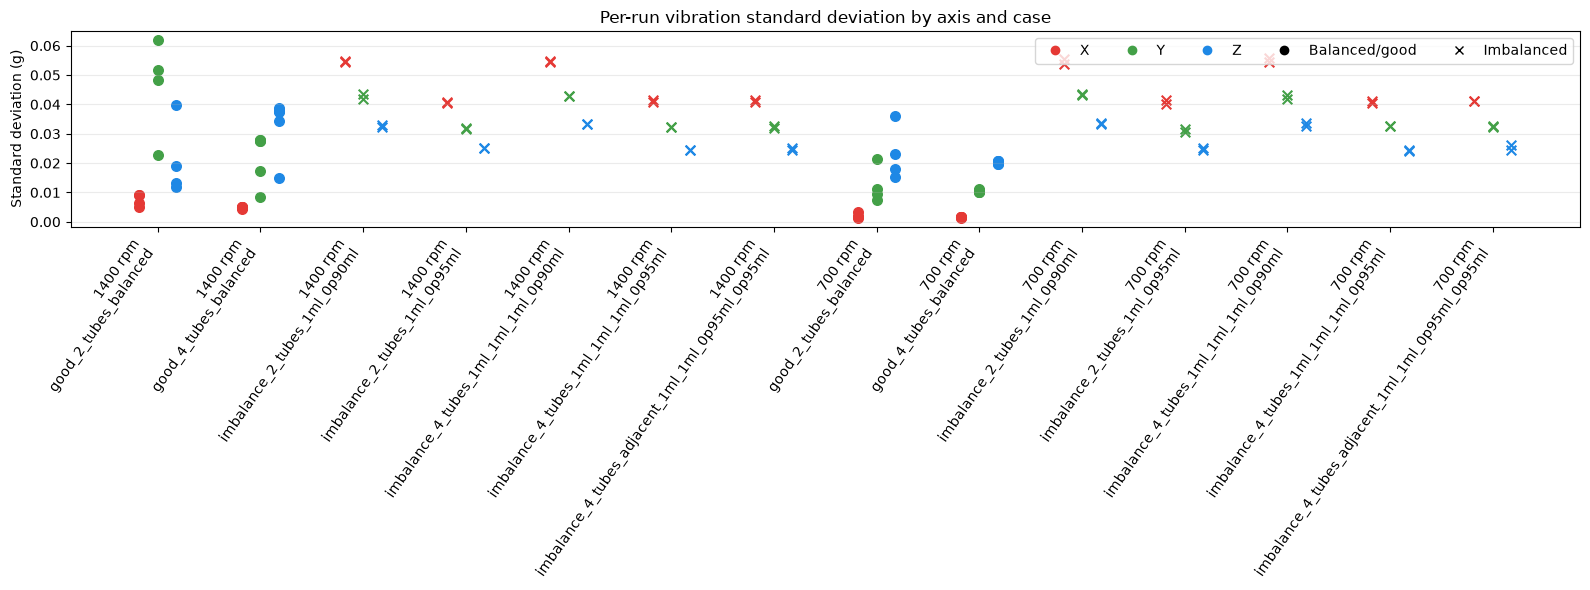

In [19]:
case_names = [f"{r.rpm} rpm\n{r.condition}" for r in run_features.itertuples()]
case_order = list(dict.fromkeys(case_names))
case_x = {name: i for i, name in enumerate(case_order)}
offsets = {"X": -0.18, "Y": 0.0, "Z": 0.18}
fig, ax = plt.subplots(figsize=(16, 6))
for row, case in zip(run_features.itertuples(), case_names):
    marker = "x" if row.label_imbalanced else "o"
    for axis in AXES:
        ax.scatter(case_x[case] + offsets[axis], getattr(row, f"{axis}_std"),
                   color=COLORS[axis], marker=marker, s=48)
ax.set_ylabel("Standard deviation (g)")
ax.set_xticks(range(len(case_order)), case_order, rotation=55, ha="right")
ax.grid(axis="y", alpha=0.25)
legend = [Line2D([0], [0], color=COLORS[a], marker="o", linestyle="", label=a) for a in AXES]
legend += [Line2D([0], [0], color="black", marker="o", linestyle="", label="Balanced/good"),
           Line2D([0], [0], color="black", marker="x", linestyle="", label="Imbalanced")]
ax.legend(handles=legend, ncol=5, loc="upper right")
ax.set_title("Per-run vibration standard deviation by axis and case")
fig.tight_layout()
plt.show()

## Waveform overlays

Compare one balanced/good run with one imbalanced run at each speed. Colors identify axes; solid lines are good and dashed lines are imbalanced.


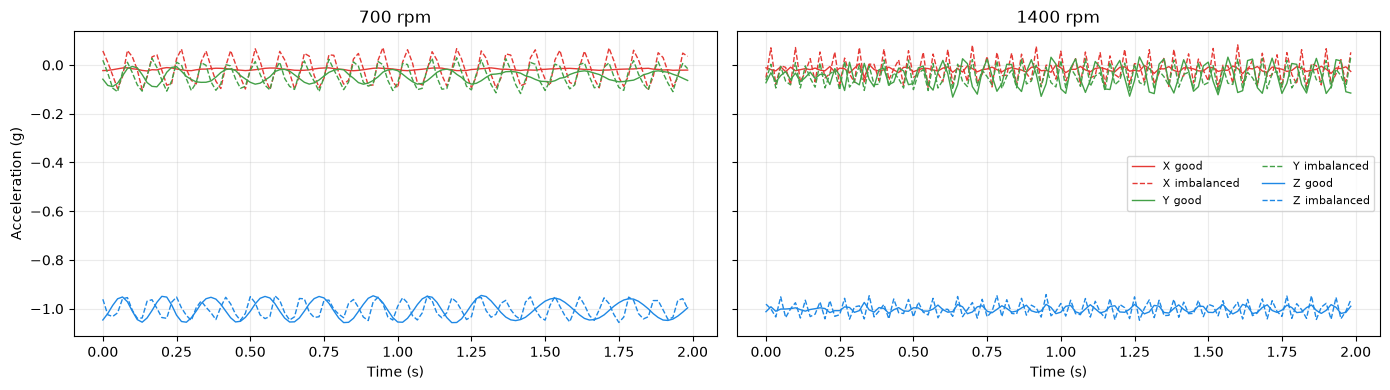

In [20]:
signals = {run_id: waveform for run_id, waveform, _ in run_arrays}
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
time = np.arange(120) / 60.0
for ax, rpm in zip(axes, (700, 1400)):
    good = run_features[(run_features.rpm == rpm) & (run_features.label_imbalanced == 0)].iloc[0]
    faulty = run_features[(run_features.rpm == rpm) & (run_features.label_imbalanced == 1)].iloc[0]
    for j, axis in enumerate(AXES):
        ax.plot(time, signals[good.run_id][:, j], color=COLORS[axis],
                linestyle="-", linewidth=1, label=f"{axis} good")
        ax.plot(time, signals[faulty.run_id][:, j], color=COLORS[axis],
                linestyle="--", linewidth=1, label=f"{axis} imbalanced")
    ax.set_title(f"{rpm} rpm")
    ax.set_xlabel("Time (s)")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Acceleration (g)")
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## FFT spectra

Compare frequency amplitudes for one balanced/good run and one imbalanced run at each speed. Each panel overlays the X, Y, and Z axis spectra.


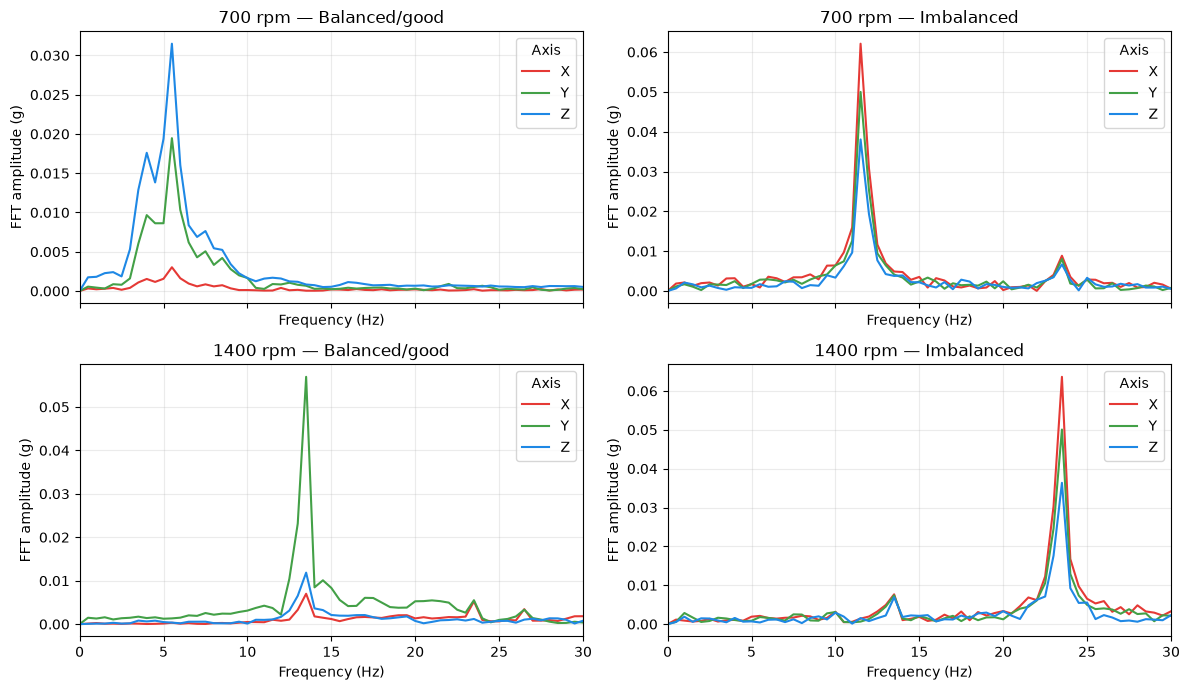

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for row, rpm in enumerate((700, 1400)):
    good = run_features[(run_features.rpm == rpm) & (run_features.label_imbalanced == 0)].iloc[0]
    faulty = run_features[(run_features.rpm == rpm) & (run_features.label_imbalanced == 1)].iloc[0]
    for col, (case, title) in enumerate(((good, "Balanced/good"), (faulty, "Imbalanced"))):
        ax = axes[row, col]
        xyz = signals[case.run_id]
        freq = np.fft.rfftfreq(len(xyz), d=1 / 60)
        for axis_index, axis_name in enumerate(AXES):
            centered = xyz[:, axis_index] - xyz[:, axis_index].mean()
            amplitude = 2 * np.abs(np.fft.rfft(centered)) / len(centered)
            ax.plot(freq, amplitude, color=COLORS[axis_name], label=axis_name)
        ax.set_xlim(0, 30)
        ax.set_title(f"{rpm} rpm — {title}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("FFT amplitude (g)")
        ax.grid(alpha=0.25)
        ax.legend(title="Axis")
fig.tight_layout()
plt.show()


## Train, validation, and test split

The split is by run, not by individual samples, to prevent samples from one recording appearing in multiple splits. The validation set selects the model; the test set remains untouched until that choice is made.

In [22]:
SEED = 42
X_trainval, X_test, y_trainval, y_test, id_trainval, id_test = train_test_split(
    X, y, np.array([a[0] for a in run_arrays]), test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)
print("train / validation / test runs:", len(y_train), len(y_val), len(y_test))

train / validation / test runs: 24 8 8


## Compare the three Sequential CNNs

Each model standardizes X/Y/Z using mean and variance from the training split only; the normalization is saved inside the model. All use Adam, a linear logit output, and binary cross-entropy with `from_logits=True`. We select the model with the lowest validation loss. Inference reports the sigmoid-transformed output as an uncalibrated percentage score; no cutoff is applied in the notebook.


,model,validation_loss
0,Model C,0.002710
1,Model B,0.019170
2,Model A,0.094171


Selected Model C: lowest validation loss.


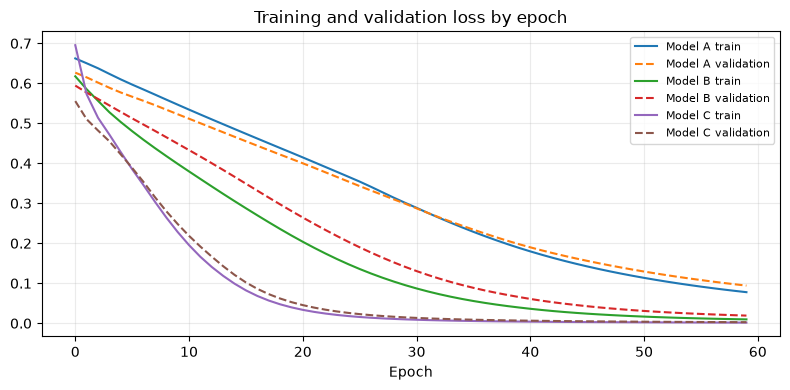

In [23]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[],
    )
    return model

# Fit per-axis normalization on training data only; it is saved inside each model.
mean = X_train.mean(axis=(0, 1))
variance = X_train.var(axis=(0, 1)) + 1e-7
def normalize():
    return layers.Normalization(axis=-1, mean=mean, variance=variance)

# Model A: one temporal convolution; Model B: two smaller convolutions; Model C: two wider convolutions.
models = [
    ("Model A", compile_model(keras.Sequential([
        layers.Input((120, 3)), normalize(), layers.Conv1D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling1D(2), layers.GlobalAveragePooling1D(), layers.Dense(16, activation="relu"), layers.Dense(1),
    ]))),
    ("Model B", compile_model(keras.Sequential([
        layers.Input((120, 3)), normalize(), layers.Conv1D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling1D(2), layers.Conv1D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling1D(2), layers.GlobalAveragePooling1D(), layers.Dense(16, activation="relu"), layers.Dense(1),
    ]))),
    ("Model C", compile_model(keras.Sequential([
        layers.Input((120, 3)), normalize(), layers.Conv1D(32, 5, padding="same", activation="relu"),
        layers.MaxPooling1D(2), layers.Conv1D(32, 5, padding="same", activation="relu"),
        layers.MaxPooling1D(2), layers.GlobalAveragePooling1D(), layers.Dense(16, activation="relu"), layers.Dense(1),
    ]))),
]

results, histories = [], {}
for name, model in models:
    tf.keras.utils.set_random_seed(SEED)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=60, batch_size=8,
                        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
                        verbose=0)
    histories[name] = history.history
    m = model.evaluate(X_val, y_val, verbose=0, return_dict=True)
    results.append({"model": name, "validation_loss": m["loss"]})

validation_results = pd.DataFrame(results).sort_values("validation_loss").reset_index(drop=True)
display(validation_results)
best_name = validation_results.loc[0, "model"]
best_model = dict(models)[best_name]
print(f"Selected {best_name}: lowest validation loss.")

# Training/validation curves are a simple bias–variance diagnostic.
fig, ax = plt.subplots(figsize=(8, 4))
for name, h in histories.items():
    ax.plot(h["loss"], label=f"{name} train")
    ax.plot(h["val_loss"], linestyle="--", label=f"{name} validation")
ax.set_title("Training and validation loss by epoch")
ax.set_xlabel("Epoch")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Final test result and saved model

Evaluate the selected model on held-out test runs and report its sigmoid-transformed output as an uncalibrated percentage score. No threshold or binary decision is applied.


In [24]:
test_loss = best_model.evaluate(X_test, y_test, verbose=0)
print(f"{best_name} test loss: {test_loss:.4f}")
logits = best_model(X_test, training=False).numpy().ravel()
risk_scores = tf.math.sigmoid(logits).numpy()
test_results = pd.DataFrame({
    "run_id": id_test, "true_imbalanced": y_test,
    "imbalance_model_score_percent_uncalibrated": np.round(100 * risk_scores, 1),
}).merge(metadata[["run_id", "rpm"]], on="run_id")
display(test_results)
model_path = ROOT / "centrifuge_imbalance.keras"
best_model.save(model_path)
print(f"Saved {best_name} to {model_path}")

Model C test loss: 0.0006


,run_id,true_imbalanced,imbalance_model_score_percent_uncalibrated,rpm
0,1400rpm_good_4_tubes_balanced_run04,0,0.000000,1400
1,700rpm_good_4_tubes_balanced_run01,0,0.300000,700
2,700rpm_imbalance_4_tubes_1ml_1ml_1ml_0p95ml_run02,1,99.900002,700
3,700rpm_imbalance_2_tubes_1ml_0p90ml_run02,1,100.000000,700
4,1400rpm_good_4_tubes_balanced_run03,0,0.000000,1400
5,1400rpm_imbalance_2_tubes_1ml_0p90ml_run02,1,100.000000,1400
6,700rpm_good_2_tubes_balanced_run01,0,0.000000,700
7,1400rpm_imbalance_2_tubes_1ml_0p90ml_run01,1,100.000000,1400


Saved Model C to /Users/samarthsethi/projects/hackathon/centrifuge_imbalance.keras
